# Day 11(M3 Day02) 확장 실습 — 투자 리서치 어시스턴트

**목표**: '야후파이낸스 기반 투자보고서 생성 서비스'를 도구 에이전트로 바꾼다. 종목 검색·기본 정보·재무제표·보고서 저장을 도구로 주고, 세션 기억과 사실 기억으로 이어지는 질문과 사용자 성향을 다룬다.

**선수**: `Day11-세션메모리와문맥유지-실습.ipynb` Part 4 (4-3~4-5 선택 과제 포함). 이 노트북은 그 노트북 없이도 실행되도록 Part 4에서 만든 함수를 0절에 다시 모았다.

> **참고:** `.env`의 `OPENAI_API_KEY`·`DATABASE_URL`(Supabase Session pooler)을 확인한다. `uv add psycopg2-binary yfinance tabulate`가 필요하다(이미 설치돼 있다면 생략).

## 한 턴의 흐름

> **참고:** 이 흐름의 시퀀스 다이어그램은 배포용 문서 「2_PostgreSQL 세션 메모리와 사용자별 문맥 유지」 7-1에 있다.

①~⑨는 코드가 정한 순서대로 매 턴 실행된다. `loop` 구간만 에이전트가 정한다(어떤 도구를 몇 번 부를지).

| 번호 | 호출 | 하는 일 | 만든 곳 |
| --- | --- | --- | --- |
| ① | `input_guard(text)` | 위험한 입력이면 여기서 끝낸다 | Day11 Part 3 |
| ② | `make_report_tools(user_id)` | 이 사용자 전용 보고서 도구를 만든다. `research_chat`이 `agent_chat`에 넘길 인자를 만들면서 부른다 | 이 노트북 |
| ③ | `agent_chat(...)` | 주식 도구(`STOCK_TOOLS`)와 ②, `RESEARCH_SYSTEM`을 넘긴다 | Day11 4-5 |
| ④ | `make_fact_tools(user_id)` | 이 사용자 전용 사실 기억 도구를 만든다 | Day11 4-2 |
| ⑤ | `create_agent(llm, 도구 목록, system_prompt)` | ②·④와 주식 도구로 에이전트를 만든다. 사용자마다 도구가 달라서 **매 턴 새로 만든다** | Day11 4-5 |
| ⑥ | `load_agent(session_id)` | 이 세션의 지난 메시지를 불러온다 | Day11 4-3 |
| ⑦ | `safe_recent(…, 12)` | 도구 호출과 결과의 짝을 지키며 최근 12개만 남긴다 | Day11 4-4 |
| ⑧ | `agent.invoke(...)` | 지난 메시지 + 새 질문으로 실행한다 | — |
| ⑨ | `save_message(session_id, m)` | 이번 턴에 새로 생긴 메시지만 저장한다 | Day11 4-3 |

> **참고:** ②와 ④에서 `user_id`를 코드가 넣기 때문에, 에이전트는 다른 사용자의 사실이나 보고서에 접근할 수 없다(Day11 4-1 "왜 함수 안에서 `@tool`을 만드나").

## 구성 한눈에 보기

### 함수와 도구 묶음

> **참고:** 함수와 도구 묶음의 관계도는 배포용 문서 「2_PostgreSQL 세션 메모리와 사용자별 문맥 유지」 7-2에 있다.

도구마다 LLM이 채우는 인자와 코드가 고정하는 값이 다르다.

| 도구 | LLM이 채우는 인자 | 코드가 고정하는 값 |
| --- | --- | --- |
| `remember_fact` | `key`, `value` | `user_id` |
| `recall_facts` | 없음 | `user_id` |
| `save_report` | `symbol`, `report` | `user_id` |
| `list_reports` | 없음 | `user_id` |
| `search_symbol` | `query` | — |
| `get_basic_info`, `get_financials` | `symbol` | — (결과는 `cache_get`·`cache_put`으로 캐시) |

### 도구와 테이블

> **참고:** 도구와 테이블의 관계도는 배포용 문서 「2_PostgreSQL 세션 메모리와 사용자별 문맥 유지」 7-3에 있다.

도구 묶음마다 쓰는 테이블이 하나씩이다. `user_facts`의 기본 키가 `(user_id, key)`라서 같은 사용자가 같은 key를 다시 저장하면 값이 바뀐다. `stock_cache`의 기본 키에 `fetched_on`(날짜)이 있어서 날이 바뀌면 다시 조회한다.

## 0. 환경 준비 — Day11 Part 4에서 만든 것

DB 연결과 LLM, 그리고 Day11 Part 4에서 만든 함수를 다시 정의한다. 새로 배우는 내용은 아니므로 실행만 한다. 셀 하나에 한 가지씩 나눴다.

| 함수 | Day11 절 | 하는 일 |
| --- | --- | --- |
| `input_guard` | Part 3 (M1 Day04) | 위험한 입력 차단 |
| `make_fact_tools` | 4-2 | 사용자 사실 저장·조회 도구 (`user_facts`) |
| `save_message`, `load_agent` | 4-3 | 도구 호출이 들어간 대화 저장·복원 (`agent_messages`) |
| `safe_recent` | 4-4 | 도구 호출과 결과의 짝을 지키며 최근 N개 자르기 |
| `agent_chat` | 4-5 | 세션 기록을 불러와 `create_agent` 실행, 새 메시지 저장 |

In [105]:
# Day11 본 실습에서 만든 것을 다시 정의한다. 새로 배우는 내용이 아니므로 실행만 한다
import os
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGCHAIN_TRACING_V2"] = "false"

import psycopg2
from psycopg2.extras import Json
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain.agents import create_agent
from dotenv import load_dotenv

import yfinance as yf
import pandas as pd

In [106]:
load_dotenv()
conn = psycopg2.connect(os.getenv("DATABASE_URL"))
conn.autocommit = True
cur = conn.cursor()

llm = ChatOpenAI(model='gpt-4o-mini')
print('DB & LLM 준비')

DB & LLM 준비


In [107]:
# Part 3 (M1 Day04) — 위험한 입력·출력 막기
DANGER_PATTERNS = ["이전 지시", "무시하고", "시스템 프롬프트", "역할을 바꿔"]
FORBIDDEN = ["시스템 프롬프트", "내부 지시"]

def input_guard(text):
    return any(p in text for p in DANGER_PATTERNS)

def output_guard(text):
    return not any(f in text for f in FORBIDDEN)

In [108]:
# 4-2 — 사용자 사실 저장·조회 도구 (user_id는 코드가 넣는다. 4-1 "왜 함수 안에서 @tool을 만드나")
cur.execute("""
    CREATE TABLE IF NOT EXISTS user_facts (
        user_id TEXT NOT NULL,
        key TEXT NOT NULL,
        value TEXT,
        PRIMARY KEY (user_id, key)
    )
""")

In [109]:
# 클로저: user_id는 외부에서 고정하고, LLM은 key와 value만 전달한다.
def make_fact_tool(user_id: str):
    @tool
    def remember_fact(key: str, value: str) -> str:
        """사용자의 사실을 key-value 형태로 저장한다. 같은 key를 다시 저장하면 값을 수정한다."""
        key = key.strip()
        value = value.strip()
        if not key:
            return "저장 실패: key는 빈 문자열일 수 없습니다."

        try:
            # 정상 종료 시 commit, 예외 발생 시 rollback된다.
            with conn:
                with conn.cursor() as cur:
                    cur.execute(
                        """
                        INSERT INTO user_facts (user_id, key, value)
                        VALUES (%s, %s, %s)
                        ON CONFLICT (user_id, key)
                        DO UPDATE SET value = EXCLUDED.value
                        """,
                        (user_id, key, value),
                    )
            return f"저장 완료: {key} = {value}"
        except Exception as e:
            return f"사실 저장 중 오류가 발생했습니다: {e}"

    @tool
    def recall_facts() -> str:
        """현재 사용자에 대해 저장된 모든 사실을 조회한다."""
        try:
            with conn:
                with conn.cursor() as cur:
                    cur.execute(
                        """
                        SELECT key, value
                        FROM user_facts
                        WHERE user_id = %s
                        ORDER BY key
                        """,
                        (user_id,),
                    )
                    rows = cur.fetchall()

            if not rows:
                return "저장된 사실이 없습니다."
            return "\n".join(f"{key}: {value}" for key, value in rows)
        except Exception as e:
            return f"사실 조회 중 오류가 발생했습니다: {e}"

    return [remember_fact, recall_facts]

In [110]:
# make_fact_tool 테스트 — 테스트용 사용자로 도구를 직접 불러 본다 (LLM 없이)
FACT_TEST_USER = "test-fact-user"
remember_fact, recall_facts = make_fact_tool(FACT_TEST_USER)


print(remember_fact.invoke({"key": "투자성향", "value": "안정형"}))
print(remember_fact.invoke({"key": "투자성향", "value": "공격형"}))   # 같은 key를 다시 저장하면 값이 바뀐다
print(remember_fact.invoke({"key": "관심분야", "value": "반도체"}))
print("[조회]")
print(recall_facts.invoke({}))


# 다른 사용자의 도구로는 이 사실이 보이지 않아야 한다 (user_id를 코드가 넣기 때문)
other_remember, other_recall = make_fact_tool("test-other-user")
print("[다른 사용자로 조회]", other_recall.invoke({}))


저장 완료: 투자성향 = 안정형
저장 완료: 투자성향 = 공격형
저장 완료: 관심분야 = 반도체
[조회]
관심분야: 반도체
투자성향: 공격형
[다른 사용자로 조회] 저장된 사실이 없습니다.


In [111]:
SYSTEM_FACTS = SystemMessage(
    "사용자가 오래 기억할 만한 사실(이름, 희망 직무, 사는 곳 등)을 말하면 remember_fact로 저장한다. "
    "사용자가 자기 자신에 대해 묻거나('내 직무', '나 기억해?'), 사용자에게 맞춘 답이 필요하면 "
    "답하기 전에 먼저 recall_facts를 호출한다.")

In [112]:
# 4-3 — 도구 호출이 들어간 대화를 저장·복원한다
# agent_messages 테이블 생성
cur.execute("""
CREATE TABLE IF NOT EXISTS agent_messages (
    id serial PRIMARY KEY,
    session_id text,
    role text,
    content text,
    tool_calls jsonb,        -- AI가 호출한 도구 목록 (AI 메시지에만)
    tool_call_id text,       -- 어느 호출에 대한 결과인지 (도구 메시지에만)
    created_at timestamptz DEFAULT now()
)""")


In [113]:
MSG_TYPE_TO_ROLE = {"human": "user", "ai": "ai", "tool": "tool"}

def save_message(session_id, m):
    cur.execute("""INSERT INTO agent_messages (session_id, role, content, tool_calls, tool_call_id)
                    VALUES ( %s, %s, %s, %s, %s )""",
                    (session_id, MSG_TYPE_TO_ROLE[m.type], m.content,
                      Json(m.tool_calls) if getattr(m, 'tool_calls', None) else None,
                        getattr(m, 'tool_call_id', None)))

def load_agent(session_id):
    cur.execute("""SELECT role, content, tool_calls, tool_call_id FROM agent_messages
                    WHERE session_id = %s ORDER BY created_at
                """, (session_id,))
    out = cur.fetchall()
    result = []
    for role, content, tool_calls, tool_call_id in out:
        if role == 'user':
            result.append(HumanMessage(content))
        elif role == 'ai': #ai message의 경우 tool_calls가 있을때 또는 없을때 나누어 처리
            result.append(AIMessage(content, tool_calls=tool_calls or []))
        elif role == 'tool':
            result.append(ToolMessage(content, tool_call_id=tool_call_id))
    return result


In [114]:
# 4-4 — 도구 호출과 결과의 짝을 지키며 최근 n개만 남긴다
MSG_TEST_SESSION = "test-session"
call = {"name": "recall_facts", "args":{}, "id":"call_test_1"}

test_messages = [
    HumanMessage("내 투자 성향을 기억해?"),
    AIMessage("", tool_calls=[call]),
    ToolMessage("투자성향: 안정형", tool_call_id="call_test_1"),
    AIMessage("안정형이라고 기억하고 있어요.")
]

for m in test_messages:
    save_message(MSG_TEST_SESSION, m)

In [115]:
load_agent(MSG_TEST_SESSION)

[HumanMessage(content='내 투자 성향을 기억해?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'recall_facts', 'args': {}, 'id': 'call_test_1', 'type': 'tool_call'}], invalid_tool_calls=[]),
 ToolMessage(content='투자성향: 안정형', tool_call_id='call_test_1'),
 AIMessage(content='안정형이라고 기억하고 있어요.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

## 투자 리서치 어시스턴트 — 도구·세션 기억·보고서 저장

'야후파이낸스 기반 투자보고서 생성 서비스'를 도구 에이전트로 바꾼다. 원래 서비스는 종목 검색 → 데이터 수집 → 보고서 생성을 정해진 순서로 한 번 돌렸다. 여기서는 각 단계를 도구로 주고, 에이전트가 질문에 맞춰 골라 쓰게 한다. 이어지는 질문은 세션 기억으로, 사용자 성향은 `user_facts`로, 보고서는 DB에 저장한다.

| 원래 서비스 | 여기서 |
| --- | --- |
| Meilisearch 종목 검색 (별도 서버) | `search_symbol` 도구 (`yf.Search`) |
| `get_basic_info`, `get_financial_statement` | 같은 이름의 도구 + DB 캐시 |
| 한 번 만들고 끝 | 세션 기억으로 이어지는 질문 |
| 확장 아이디어 "보고서 아카이빙(DB)" | `save_report`, `list_reports` 도구 |

> **주의:** 교육용 예제다. 생성된 보고서는 투자 권유가 아니다. yfinance는 Yahoo가 공식 제공하는 API가 아니어서 응답 형식이 바뀌거나 요청이 막힐 수 있다.

### 조회 결과 캐시

교육장에서 여러 명이 같은 종목을 반복 조회하면 요청이 막힐 수 있다. 같은 날 같은 종목은 DB에 저장해 둔 결과를 쓴다.

In [116]:
cur.execute("""
    CREATE TABLE IF NOT EXISTS stock_cache (
        symbol     TEXT NOT NULL,
        kind       TEXT NOT NULL,
        fetched_on DATE NOT NULL DEFAULT CURRENT_DATE,
        body       TEXT,
        PRIMARY KEY (symbol, kind, fetched_on)
    )
""")

In [117]:
def cache_get(symbol,kind):
    """캐시 테이블에서 종목 조회, 없으면 None"""
    with conn.cursor() as c:
        c.execute("""SELECT body FROM stock_cache
                     WHERE symbol = %s AND kind = %s
                        AND fetched_on = current_date""", (symbol, kind))
        row = c.fetchone()
       
    # TODO: row가 있으면 row[0](저장된 body)을, 없으면 None을 돌려주세요
        if row :
            return row[0]
    return None


def cache_put(symbol, kind, body):
    """종목의 정보를 오늘 날짜로 저장한다."""
    with conn.cursor() as c:
        c.execute("""INSERT INTO stock_cache (symbol, kind, body)
                  VALUES (%s, %s, %s) ON CONFLICT DO NOTHING""",
                  (symbol, kind, body))


In [ ]:
CACHE_TEST_SYMBOL = "TEST_SYMBOL"
cache_get(CACHE_TEST_SYMBOL, "info")

In [118]:
cache_put(CACHE_TEST_SYMBOL, "info", "첫번째 info")

In [119]:
cache_get(CACHE_TEST_SYMBOL, "info")

'첫번째 info'

### 주식 도구

원래 서비스의 `.loc[[...]]`는 항목이 하나라도 없으면 `KeyError`로 멈춘다. 은행 종목은 `Gross Profit`이 없으므로 있는 항목만 고른다.

금액은 **코드에서 억 달러로 바꿔서** 넘긴다. 처음 버전은 원래 숫자(`109417000000`)를 그대로 넘겼는데, 모델이 이를 "109,417억 달러"로 잘못 바꿔 적었다. 단위 계산은 코드가 하고, 모델은 받은 숫자를 옮겨 적기만 하게 한다.

In [120]:
INFO_FIELDS = ["longName", "sector", "industry", "marketCap", "sharesOutstanding"]
EOK = 100_000_000   # 1억


@tool
def search_symbol(query: str) -> str:
    """회사 이름(영문)으로 미국 주식 종목 심볼을 찾는다. 예: 'apple' → AAPL"""
    quotes = yf.Search(query, max_results=5).quotes
    hits = [f"{q['symbol']}: {q.get('shortname', '')}" for q in quotes if q.get("quoteType") == "EQUITY"]
    return "\n".join(hits) or "검색 결과 없음"


In [121]:
@tool
def get_basic_info(symbol: str) -> str:
    """종목 심볼의 회사명, 섹터, 산업, 시가총액, 발행주식수를 가져온다."""
    symbol = symbol.upper()

    # 종목정보의 캐시에 존재 유무 확인
    body = cache_get(symbol, "info")
    if body:                                      # 오늘 이미 조회했다
        return body

    # 캐시에 없을 때 새로 조회
    info = yf.Ticker(symbol).info

    row = {k: info.get(k, "정보 없음") for k in INFO_FIELDS}
    if isinstance(row["marketCap"], (int, float)):
        row["marketCap"] = f"{row['marketCap'] / EOK:,.0f}억 달러"
    if isinstance(row["sharesOutstanding"], (int, float)):
        row["sharesOutstanding"] = f"{row['sharesOutstanding'] / EOK:,.1f}억 주"
    body = pd.Series(row, name=symbol).to_markdown()
    
    # info 캐시에 저장
    cache_put(symbol, "info", body)
    return body


In [122]:
@tool
def get_financials(symbol: str) -> str:
    """종목 심볼의 최근 분기 손익계산서, 재무상태표, 현금흐름표 핵심 항목을 가져온다. 단위는 억 달러다."""
    symbol = symbol.upper()

    # 캐시에 확인
    body = cache_get(symbol, "financials")
    if body:
        return body

    # 없으면 새로 조회
    t = yf.Ticker(symbol)
    statements = [
        ("손익계산서", t.quarterly_income_stmt, ["Total Revenue", "Gross Profit", "Operating Income", "Net Income"]),
        ("재무상태표", t.quarterly_balance_sheet, ["Total Assets", "Total Liabilities Net Minority Interest", "Stockholders Equity"]),
        ("현금흐름표", t.quarterly_cash_flow, ["Operating Cash Flow", "Investing Cash Flow", "Financing Cash Flow"]),
    ]

    # 재무정보 전처리
    parts = []
    for title, df, wanted in statements:
        rows = [r for r in wanted if r in df.index]        # 없는 항목은 건너뛴다
        table = (df.loc[rows] / EOK).round(0)
        table.columns = [c.strftime("%Y-%m-%d") for c in table.columns]
        parts.append(f"### {title} (단위: 억 달러)\n" + table.to_markdown(floatfmt=",.0f"))
    body = "\n\n".join(parts)

    # 재무정보 캐시에 저장
    cache_put(symbol, "financials", body)
    return body


In [123]:
print(search_symbol.invoke({"query": "apple"})) # 종목명

AAPL: Apple Inc.
APLE: Apple Hospitality REIT, Inc.
AAPL.TO: APPLE CDR (CAD HEDGED)


In [124]:
print(get_basic_info.invoke({"symbol": "AAPL"})) #티커, 종목코드

|                   | AAPL                 |
|:------------------|:---------------------|
| longName          | Apple Inc.           |
| sector            | Technology           |
| industry          | Consumer Electronics |
| marketCap         | 49,387억 달러        |
| sharesOutstanding | 145.9억 주           |


# uv add tabluate

In [125]:
print(get_financials.invoke({"symbol": "AAPL"})[:400])

### 손익계산서 (단위: 억 달러)
|                  |   2026-06-30 |   2026-03-31 |   2025-12-31 |   2025-09-30 |   2025-06-30 |
|:-----------------|-------------:|-------------:|-------------:|-------------:|-------------:|
| Total Revenue    |        1,094 |        1,112 |        1,438 |        1,025 |          940 |
| Gross Profit     |          548 |          548 |          692 |          483 |          4


### 보고서 저장 도구

In [126]:
cur.execute("""
CREATE TABLE IF NOT EXISTS stock_reports (
    id serial PRIMARY KEY,
    user_id text,
    symbol text,
    report text,
    created_at timestamptz DEFAULT now()
)""")

파이썬 스크립트 > ***.py

In [127]:
def make_report_tools(user_id):
    @tool
    def save_report(symbol: str, report: str) -> str:
        """완성한 투자 보고서 전문을 저장한다. 사용자가 저장을 요청할 때만 쓴다."""
        with conn.cursor() as c:
            c.execute("INSERT INTO stock_reports (user_id, symbol, report) VALUES (%s, %s, %s) RETURNING id",
                      (user_id, symbol.upper(), report))
            return f"보고서 저장함 (번호 {c.fetchone()[0]})"


    @tool
    def list_reports() -> str:
        """이 사용자가 저장한 보고서 목록(번호, 종목, 저장일, 첫 줄)을 가져온다."""
        with conn.cursor() as c:
            # 날짜는 한국 시간으로 바꿔 읽는다 (DB는 UTC로 저장한다)
            c.execute("""SELECT id, symbol, (created_at AT TIME ZONE 'Asia/Seoul')::date, report
                         FROM stock_reports WHERE user_id = %s ORDER BY id""", (user_id,))
            rows = c.fetchall()
        lines = []
        for num, symbol, day, report in rows:
            first_line = report.splitlines()[0] if report else ""
            lines.append(f"{num}. {symbol} ({day}) {first_line}")
        return "\n".join(lines) or "저장된 보고서 없음"


    return [save_report, list_reports]


In [128]:
# make_report_tools 테스트 — 테스트용 사용자로 도구를 직접 불러 본다 (LLM 없이)
REPORT_TEST_USER = "test-report-user"
save_report, list_reports = make_report_tools(REPORT_TEST_USER)


print(save_report.invoke({"symbol": "aapl", "report": "애플 테스트 보고서\n둘째 줄은 목록에 나오지 않는다"}))
print(save_report.invoke({"symbol": "msft", "report": "마이크로소프트 테스트 보고서"}))
print("[목록]")
print(list_reports.invoke({}))   # 심볼은 대문자로, 보고서는 첫 줄만 나와야 한다


other_save, other_list = make_report_tools("test-other-user")
print("[다른 사용자로 목록]", other_list.invoke({}))


보고서 저장함 (번호 6)
보고서 저장함 (번호 7)
[목록]
1. AAPL (2026-09-29) 애플 테스트 보고서
2. MSFT (2026-09-29) 마이크로소프트 테스트 보고서
3. AAPL (2026-09-29) 애플 테스트 보고서
4. MSFT (2026-09-29) 마이크로소프트 테스트 보고서
6. AAPL (2026-09-29) 애플 테스트 보고서
7. MSFT (2026-09-29) 마이크로소프트 테스트 보고서
[다른 사용자로 목록] 저장된 보고서 없음


### 시스템 프롬프트와 대화 함수

원래 서비스의 시스템 프롬프트는 "clear verdicts", "predictions"를 요구해 매수·매도 판단을 유도했다. 여기서는 도구가 가져온 숫자만 쓰고 투자 권유를 하지 않도록 정한다. 인젝션 방어는 0절의 `input_guard`(M1 Day04)를 재사용한다.

In [129]:
RESEARCH_SYSTEM = """너는 미국 주식 리서치 보조다. 한국어로 답한다.
- 회사 이름만 들으면 search_symbol로 심볼부터 찾는다.
- 금액은 도구 결과의 숫자와 단위(억 달러)를 그대로 옮긴다. 단위를 바꾸거나 새로 계산하지 않는다.
- 매수나 매도를 권하거나 '주목할 만하다' 같은 평가를 하지 않는다. 보고서 끝에 '이 내용은 투자 권유가 아닙니다.'를 적는다.
- 사용자가 투자 성향이나 관심 분야를 말하면 다른 도구보다 먼저 remember_fact로 저장한다.
- 사용자가 자기 성향이나 지난 기록을 물으면 recall_facts, list_reports로 확인한다.
- 사용자가 저장을 요청하면 save_report로 보고서를 저장한다.
"""

In [130]:
# 도구 호출과 결과의 짝을 지키며 최근 n개만 남긴다
def safe_recent(msgs, n):
    start = max(len(msgs) - n, 0)
    while start > 0 and isinstance(msgs[start], ToolMessage):
        start -= 1
    return msgs[start:]

In [131]:
def agent_chat(session_id, user_id, text, extra_tools, system, keep):
    # agent 생성 (자체기능 : 팩트관리, 추가기능 : 리서치 도구)
    agent = create_agent(llm, tools=make_fact_tool(user_id)+ extra_tools, system_prompt=system)

    # 최근 대화 내역 가져오기
    history = safe_recent(load_agent(session_id), keep)

    # agent 호출
    result = agent.invoke({"messages": history + [HumanMessage(text)]}) # 대화내역 + 마지막 사용자메시지를 합쳐서 agent 호출
    
    # agent의 호출결과로 새로 추가된 메시지 생성
    new_message = result['messages'][len(history):] # 마지막 ai 생성 메시지만 추출
    
    # 메시지를 저장
    for m in new_message:
        save_message(session_id, m)
        for c in getattr(m, "tool_calls", None) or []:
            print(f"   [도구 호출] {c['name']}({c['args']})")

    return result['messages'][-1].content #최종 ai 응답 반환

In [132]:
STOCK_TOOLS = [search_symbol, get_basic_info, get_financials]

# TODO: agent_chat에 주식 도구(STOCK_TOOLS)와 보고서 도구(make_report_tools)를 extra_tools로,
#       RESEARCH_SYSTEM을 system으로 넘겨 호출하고 그 결과를 반환하세요

def research_chat(session_id, user_id, text):
    if input_guard(text):
        return '[입력차단] 위험한 요청이 포함되어 있습니다.'

    return agent_chat(session_id, user_id, text, 
                      extra_tools=STOCK_TOOLS + make_report_tools(user_id),
                      system=RESEARCH_SYSTEM, keep=10
                      )

In [133]:
TEST_SESSION_ID = 'invest_test1'
TEST_USER_ID = 'investor_test1'

print(research_chat(TEST_SESSION_ID, TEST_USER_ID, "삼성전자 주식 어떻게 되니?"))

   [도구 호출] search_symbol({'query': 'Samsung Electronics'})
   [도구 호출] get_basic_info({'symbol': 'SSNLF'})
삼성전자(Samsung Electronics Co., Ltd.)에 대한 정보는 다음과 같습니다:

- **섹터**: 기술 (Technology)
- **산업**: 소비자 전자 (Consumer Electronics)
- **시가총액**: 4,282억 달러
- **발행 주식 수**: 57.6억 주

이 내용은 투자 권유가 아닙니다.


In [134]:
print(research_chat(TEST_SESSION_ID, TEST_USER_ID, "하이닉스 투자보고서 정리하고, 저장해줘"))

   [도구 호출] search_symbol({'query': 'SK Hynix'})
   [도구 호출] get_basic_info({'symbol': 'SKHY'})
   [도구 호출] get_financials({'symbol': 'SKHY'})
하이닉스(SK Hynix Inc.)에 대한 투자 보고서는 다음과 같습니다:

### 기본 정보
- **회사명**: SK hynix Inc.
- **섹터**: 기술 (Technology)
- **산업**: 반도체 (Semiconductors)
- **시가총액**: 12,936억 달러
- **발행 주식 수**: 71.1억 주

### 손익계산서 (단위: 억 달러)
| 항목               |  2026-06-30 |  2026-03-31 |  2025-12-31 |  2025-09-30 |  2025-06-30 |  2025-03-31 |  2024-12-31 |
|:------------------|-------------:|-------------:|-------------:|-------------:|-------------:|-------------:|-------------:|
| 총 수익           |      793,187 |      525,763 |      328,267 |      244,489 |      222,320 |          nan |          nan |
| 총 이익           |      659,914 |      416,794 |      225,764 |      140,291 |      119,833 |          nan |          nan |
| 운영 이익         |      605,426 |      376,103 |      191,696 |      113,834 |       92,129 |          nan |          nan |
| 순이익            |      938,202 |      4

In [103]:
print(research_chat(TEST_SESSION_ID, TEST_USER_ID, "애플의 최근 실적을 짧은 보고서로 작성해줘. 참고로 나는 배당보다 성장성을 더 중요하게 생각해"))

   [도구 호출] search_symbol({'query': 'apple'})
   [도구 호출] get_basic_info({'symbol': 'AAPL'})
   [도구 호출] get_financials({'symbol': 'AAPL'})
애플(Apple Inc.)의 최근 실적에 대한 간략한 보고서는 아래와 같습니다.

### 기본 정보
- **회사명**: Apple Inc.
- **산업**: 소비자 전자 제품 (Consumer Electronics)
- **섹터**: 기술 (Technology)
- **시가총액**: 49,387억 달러
- **발행주식수**: 145.9억 주 

### 최근 분기 손익계산서 (단위: 억 달러)
| 항목               | 2026-06-30 | 2026-03-31 | 2025-12-31 | 2025-09-30 | 2025-06-30 |
|--------------------|-------------|-------------|-------------|-------------|-------------|
| 총 수익             | 1,094       | 1,112       | 1,438       | 1,025       | 940         |
| 매출 총이익         | 548         | 548         | 692         | 483         | 437         |
| 운영 이익           | 357         | 359         | 509         | 324         | 282         |
| 순이익             | 298         | 296         | 421         | 275         | 234         |

### 최근 분기 재무상태표 (단위: 억 달러)
| 항목                             | 2026-06-30 | 2026-03-31 | 2025-12-31 | 2

### 테스트 ①의 도구 호출 순서 (처음 조회할 때)

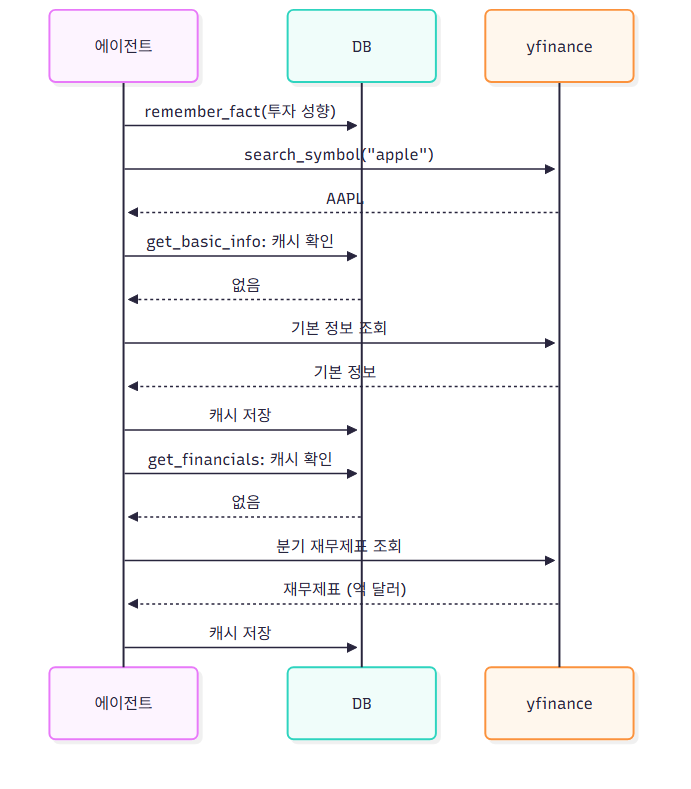

`get_basic_info`·`get_financials`는 먼저 `stock_cache`를 확인하고, 없을 때만 yfinance를 부른다. 같은 날 같은 종목을 다시 물으면 캐시 확인에서 바로 돌아오므로 yfinance 호출이 없다. 실제 순서는 테스트 ① 출력의 `[도구 호출]` 줄로 확인한다.

### 테스트 ① — 회사 이름으로 보고서

### 테스트 ② — 이어지는 질문 (세션 기억)

### 테스트 ③ — 비교 (도구 여러 번)

### 테스트 ④ — 보고서 저장

### 테스트 ⑤ — 새 대화방 (사실 기억 + 저장된 보고서)

### 테스트 ⑥ — 항목이 다른 종목 (은행)

### 테스트 ⑦ — 인젝션 시도

### 관찰

| 테스트 | 확인할 것 |
| --- | --- |
| ① | 회사 이름 → `search_symbol` → 데이터 도구 순서로 호출했는가. 성향을 `remember_fact`로 저장했는가 |
| ② | "그 회사"를 대화 기록으로 알아들었는가. 도구를 다시 부르지 않고 앞 턴의 결과로 답했는가. 추세 설명이 표 숫자와 맞는가 |
| ③ | 두 종목 데이터를 모두 가져와 비교했는가. 숫자가 도구 결과와 같은가 |
| ④·⑤ | 저장한 보고서와 성향이 새 대화방에서도 나오는가 |
| ⑥ | `Gross Profit`이 없어도 멈추지 않았는가 |
| ⑦ | 에이전트까지 가기 전에 차단됐는가 |

> **주의:** 숫자는 도구가 코드로 계산해 넘겨서 정확하지만, "늘었다·줄었다" 같은 해석은 모델이 하므로 틀릴 수 있다. 해석은 표의 숫자와 대조한다.
>
> 에이전트가 도구를 몇 번, 어떤 순서로 부를지는 실행마다 달라질 수 있다. 출력의 `[도구 호출]` 줄로 실제 경로를 확인한다.

## 확인 문제

1. 원래 서비스는 검색 → 수집 → 보고서를 정해진 순서로 돌렸다. 도구 에이전트로 바꾸면 무엇이 달라지는가?
2. 금액을 코드에서 억 달러로 바꿔 넘기는 이유는?
3. 세션 기억, 사실 기억, 보고서, 조회 캐시는 각각 어느 테이블에 들어가는가?
4. 은행 종목에서 원래 서비스의 `.loc[[...]]`가 멈추는 이유와, 여기서 고친 방법은?
5. `stock_cache`가 교육장 실습에서 필요한 이유는?